# BandS_Matrix_b_mutable

**Matrix-based Branch-and-Sandwich for UC Line-Capacity Counterfactual Explanations**

This notebook finds the minimal change to transmission line capacities `b` (flow limits `fmax[ell]`)
such that a desired *foil* solution becomes cost-optimal — a **Weak Counterfactual Explanation (WCE)**.

Unlike `02_branch_sandwich_b_mutable`, the B&S solver here works directly on the
LP/MIP constraint matrix `(A_norm, rhs_norm, c)` extracted **once** from Gurobi.
No UC model is rebuilt from `NetworkUCData` at each B&S node.

### Architecture

```
build_network_uc_model(DATA)          <- called ONCE
        |
        v
extract_uc_matrices()                 <- normalise all rows to A x <= rhs
        |                               identify fmax/fmin rows by name
        v
MatrixUCOracle          <- plain & foil MIP solves, cached by b-vector
        |
        v
UCBranchAndSandwichMatrix  <- OLB (LP relax, fmax as variable)
                              ILB (LP relax, no foil)
                              OUB (multi-candidate weak-feasibility check)
                              Branch on widest free-line interval
```

### Two foil experiments (run independently)
- **Experiment A** - *Curtailment reduction*: require renewable curtailment <= (1-a)*C0
- **Experiment B** - *Emissions reduction*: require total CO2 emissions <= (1-a)*E0

### Key differences vs. `02_branch_sandwich_b_mutable`
| Aspect | Original | This notebook |
|---|---|---|
| Model rebuild per node | Yes | No - matrix reused |
| Constraint direction | Mixed <=/>=/= | All normalised to <= |
| Line-limit rows | Removed & replaced by name | RHS swapped for scalar Gurobi var |
| Foil signature | `fn(m, var_dict)` | `fn(m, x_vars_list, var_names_list)` |
| Solver class | `UCBranchAndSandwichWCE_4b` | `UCBranchAndSandwichMatrix` |

---

## Section 1 - Imports and Gurobi licence

In [1]:
import importlib, os
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace
from typing import Optional, Callable, Dict, List, Tuple

os.environ["GRB_LICENSE_FILE"] = r"C:\Users\PC3\Desktop\gurobi.lic"
# os.environ["GRB_LICENSE_FILE"] = r"C:\Users\tomas\Desktop\gurobi.lic"

import gurobipy as gp
from gurobipy import GRB

# project modules
import uc_pipeline
import uc_experiment_builders
import uc_bs_matrix

importlib.reload(uc_pipeline)
importlib.reload(uc_experiment_builders)
importlib.reload(uc_bs_matrix)

from uc_pipeline import (
    NetworkUCData, IndexMap,
    build_index_map_network_uc,
    build_cost_vector_network_uc,
    default_initial_conditions,
    build_network_uc_model,
)
from uc_experiment_builders import (
    load_network_uc_from_excel_fixed,
    make_scenario_data,
)
from uc_bs_matrix import (
    extract_uc_matrices,
    MatrixUCOracle,
    UCBranchAndSandwichMatrix,
)

print("All imports OK")

All imports OK


## Section 2 - Load scenario data

In [2]:
XLSX_PATH = r"C:\Users\PC3\Desktop\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\RedEjemploRiesgoConfiabilidad.xlsx"
# XLSX_PATH = r"C:\Users\tomas\Documents\GitHub\...\RedEjemploRiesgoConfiabilidad.xlsx"

base_data = load_network_uc_from_excel_fixed(
    xlsx_path=XLSX_PATH,
    wind_scenario=2,
    solar_scenario="Alto",
    curt_penalty=1000.0,
    allow_shifting=True,
    carbon_price=0.0,
    slack_bus=0,
)

ARCHETYPE_SEED = 7
REN_SCALE      = 2.0
DATA, types    = make_scenario_data(base_data, archetype_seed=ARCHETYPE_SEED, ren_scale=REN_SCALE)

print("Scenario ready:",
      DATA.demand.shape, "| #gens", len(DATA.gens),
      "| #rens", len(DATA.rens), "| #lines", len(DATA.lines))

Scenario ready: (14, 24) | #gens 6 | #rens 4 | #lines 20


## Section 3 - Dimensions, cost vector, b0

In [3]:
T   = int(DATA.T)
nB  = int(DATA.nB)
nG  = len(DATA.gens)
nR  = len(DATA.rens)
nL  = len(DATA.lines)

per_bus_neutrality = True
window_size        = T

idx = build_index_map_network_uc(nG=nG, nR=nR, nB=nB, nL=nL, T=T, major="t")
u_init, p_init, on_t, off_t = default_initial_conditions(DATA)

fuel_cost_vec     = np.array([g.fuel_cost     for g in DATA.gens], dtype=float)
emission_rate_vec = np.array([g.emission_rate  for g in DATA.gens], dtype=float)
no_load_cost_vec  = np.array([g.no_load_cost   for g in DATA.gens], dtype=float)
su_cost_vec       = np.array([g.SU_cost        for g in DATA.gens], dtype=float)
sd_cost_vec       = np.array([g.SD_cost        for g in DATA.gens], dtype=float)
curt_cost_mat     = (np.vstack([r.curt_cost for r in DATA.rens])
                     if nR > 0 else np.zeros((0, T), dtype=float))

cvec = build_cost_vector_network_uc(
    idx=idx,
    fuel_cost=fuel_cost_vec,
    emission_rate=emission_rate_vec,
    carbon_price=float(getattr(DATA, "carbon_price", 0.0)),
    no_load_cost=no_load_cost_vec,
    su_cost=su_cost_vec,
    sd_cost=sd_cost_vec,
    curt_cost=curt_cost_mat,
    pi_plus=DATA.pi_plus,
    pi_minus=DATA.pi_minus,
    voll=float(getattr(DATA, "voll", 20000.0)),
)

# Original line flow limits  b0[ell] = fmax of line ell
b0 = np.array([float(L.fmax) for L in DATA.lines], dtype=float)

print(f"z-vector size: {idx.n_vars} | nL={nL} | T={T}")
print(f"b0 = {b0}")

z-vector size: 2496 | nL=20 | T=24
b0 = [ 60.  60.  40.  60.  60.  50.  70.  70.  90.  90. 100. 100.  50.  90.
  90.  50.  50. 100. 100. 100.]


## Section 4 - Build UC model ONCE and extract the constraint matrix

**Why extract once?**
The UC constraint structure (generators, network, commitment logic) does NOT change
between B&S nodes - only the line-limit RHS values change.
By extracting the matrix once at `b0` and replacing the RHS of `fmax/fmin` rows with
Gurobi variables at solve time, we avoid rebuilding a ~1000-constraint model hundreds
of times.

**Normalisation rule (inside `extract_uc_matrices`)**

| Original Gurobi sense | Normalised form stored in A_norm |
|---|---|
| `a x <= rhs` | kept as-is |
| `a x >= rhs` | multiplied by -1: `-a x <= -rhs` |
| `a x = rhs`  | split into two rows: `a x <= rhs` and `-a x <= -rhs` |

After normalisation:
- `fmax[ell,t]` (originally `f <= fmax`) stays as `f[ell,t] <= fmax`
- `fmin[ell,t]` (originally `f >= -fmax`) becomes `-f[ell,t] <= fmax`

Both rows share the **same scalar** `fmax_var[ell]` at solve time -
one variable per free line drives all 2*T rows for that line.

In [4]:
# 1) Build reference model at b0  (used only for extraction)
m_ref, var_ref = build_network_uc_model(
    data=DATA,
    window_size=window_size,
    per_bus_neutrality=per_bus_neutrality,
    u_init=u_init, p_init=p_init,
    on_time_init=on_t, off_time_init=off_t,
    output_flag=0,
)

# 2) Stamp objective via set_objective_from_cvec  — CORRECT.
#    The naive loop `for i,v in enumerate(m_ref.getVars()): v.Obj=cvec[i]`
#    is WRONG because Gurobi's internal variable order != idx z-vector order.
from uc_pipeline import set_objective_from_cvec
set_objective_from_cvec(m_ref, var_ref, idx, cvec)
m_ref.update()

# 3) Extract matrices
mat = extract_uc_matrices(m_ref, nL=nL, T=T)

assert np.count_nonzero(mat['c']) > 0, "mat['c'] is all zeros — objective not stamped!"

print(f"Matrix shape       : {mat['m_norm']} rows x {mat['n']} vars")
print(f"Binary/integer vars: {len(mat['integer_vars'])}")
print(f"Non-zero cost coeff: {np.count_nonzero(mat['c'])} / {mat['n']}")
print(f"fmax rows found    : {(mat['fmax_row_idx'] >= 0).sum()}  (expected {nL*T})")
print(f"fmin rows found    : {(mat['fmin_row_idx'] >= 0).sum()}  (expected {nL*T})")

r00 = mat['fmax_row_idx'][0, 0]
print(f"\nSanity check fmax[0,0]: rhs={mat['rhs_norm'][r00]:.3f}  b0[0]={b0[0]:.3f}  "
      f"OK={abs(mat['rhs_norm'][r00] - b0[0]) < 1e-6}")


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2653481
Academic license 2653481 - for non-commercial use only - registered to to___@ug.uchile.cl
Matrix shape       : 4784 rows x 2496 vars
Binary/integer vars: 432
Non-zero cost coeff: 768 / 2496
fmax rows found    : 480  (expected 480)
fmin rows found    : 480  (expected 480)

Sanity check fmax[0,0]: rhs=60.000  b0[0]=60.000  OK=True


## Section 5 - Solve factual and select free lines by utilisation

Lines with `max_t |f[ell,t]| / fmax[ell] >= threshold` are congested or
nearly congested and are the natural candidates for capacity expansion in a WCE.

In [5]:
def make_line_weights(DATA, b0, util=None, alpha=1.0, beta=1.0, gamma=0.5, eps_u=0.05):
    """Reactance- and utilisation-based weights, normalised to mean 1."""
    b_susc  = np.array([float(L.b) for L in DATA.lines], dtype=float)
    x_proxy = 1.0 / np.maximum(np.abs(b_susc), 1e-9)
    x_med, b0_med = np.median(x_proxy), np.median(b0)
    w = (x_proxy / max(x_med, 1e-9))**alpha * (b0 / max(b0_med, 1e-9))**beta
    if util is not None:
        w *= (1.0 / (eps_u + util))**gamma
    return np.clip(w / np.mean(w), 0.1, 10.0)


# Factual solve via matrix oracle (all lines at b0, no foil)
_oracle_tmp = MatrixUCOracle(
    mat=mat, free_line_idx=list(range(nL)),
    foil_constr_fn=None, output_flag=0,
)
v0, x0 = _oracle_tmp.solve_plain(b0)
assert x0 is not None, "Factual solve failed - check matrix extraction."
print(f"Factual objective: {v0:.4f}")

# Line utilisation
f_mat     = x0[idx.f]                           # (nL, T)
f_abs_max = np.max(np.abs(f_mat), axis=1)        # (nL,)
util      = f_abs_max / np.maximum(b0, 1e-9)    # (nL,)

print("\nLine utilisation  (max_t |f[ell,t]| / fmax[ell]):")
for ell in range(nL):
    mark = "  <- free" if util[ell] >= 0.75 else ""
    print(f"  ell={ell:2d}  fmax={b0[ell]:8.1f} MW  util={util[ell]:.3f}{mark}")

UTIL_THR   = 0.75
b_free_idx = [ell for ell in range(nL) if util[ell] >= UTIL_THR]
if not b_free_idx:
    b_free_idx = list(np.argsort(-util)[:min(3, nL)])
    print(f"\nNo line above {UTIL_THR} - fallback to top-3: {b_free_idx}")
else:
    print(f"\nFree lines: {b_free_idx}")

# Domain: free lines can expand up to 5x b0; fixed lines locked at b0
bL = b0.copy()
bU = b0.copy()
for ell in b_free_idx:
    bU[ell] = 5.0 * b0[ell]

w = make_line_weights(DATA, b0, util=util)
print(f"Objective weights w[free]: {w[b_free_idx]}")

Factual objective: 2527699.6787

Line utilisation  (max_t |f[ell,t]| / fmax[ell]):
  ell= 0  fmax=    60.0 MW  util=1.000  <- free
  ell= 1  fmax=    60.0 MW  util=1.000  <- free
  ell= 2  fmax=    40.0 MW  util=1.500  <- free
  ell= 3  fmax=    60.0 MW  util=1.069  <- free
  ell= 4  fmax=    60.0 MW  util=1.038  <- free
  ell= 5  fmax=    50.0 MW  util=1.232  <- free
  ell= 6  fmax=    70.0 MW  util=0.793  <- free
  ell= 7  fmax=    70.0 MW  util=0.746
  ell= 8  fmax=    90.0 MW  util=0.667
  ell= 9  fmax=    90.0 MW  util=0.667
  ell=10  fmax=   100.0 MW  util=0.600
  ell=11  fmax=   100.0 MW  util=0.600
  ell=12  fmax=    50.0 MW  util=1.200  <- free
  ell=13  fmax=    90.0 MW  util=0.667
  ell=14  fmax=    90.0 MW  util=0.667
  ell=15  fmax=    50.0 MW  util=0.863  <- free
  ell=16  fmax=    50.0 MW  util=1.200  <- free
  ell=17  fmax=   100.0 MW  util=0.545
  ell=18  fmax=   100.0 MW  util=0.597
  ell=19  fmax=   100.0 MW  util=0.600

Free lines: [0, 1, 2, 3, 4, 5, 6, 12, 15, 16]


---
# Experiment A - Curtailment Reduction Foil

**Foil**: total renewable curtailment <= (1 - alpha) * C0

**Question**: what is the smallest capacity expansion of congested lines that makes
a low-curtailment dispatch cost-optimal?

The foil function signature for the matrix oracle is:
```python
fn(m: gp.Model, x_vars: list, var_names: list[str]) -> None
```
We locate curtailment variables via their flat z-indices in `idx.curt`.

### A.1 - Baseline curtailment and foil definition

In [6]:
curt_0 = float(np.sum(x0[idx.curt]))
print(f"Baseline total curtailment: {curt_0:.4f} MW*h")

ALPHA_CURT   = 0.20          # 20% reduction
curt_target  = (1.0 - ALPHA_CURT) * curt_0
print(f"Target ({ALPHA_CURT*100:.0f}% reduction): {curt_target:.4f} MW*h")


def make_curt_foil(curt_target: float, curt_flat_idx: list):
    """
    Returns fn(m, x_vars, var_names) that adds:
        sum_{r,t} curt[r,t]  <=  curt_target

    curt_flat_idx: list of z-indices for all curtailment variables,
                   obtained from idx.curt.flatten().tolist().
    """
    def _foil(m, x_vars, var_names):
        m.addConstr(
            gp.quicksum(x_vars[i] for i in curt_flat_idx) <= float(curt_target),
            name="foil_curt_cap",
        )
    return _foil


curt_flat_idx = idx.curt.flatten().tolist()
foil_curt     = make_curt_foil(curt_target, curt_flat_idx)

# Verify the foil is feasible at b0 before spending time on B&S
_oc = MatrixUCOracle(mat=mat, free_line_idx=b_free_idx,
                     foil_constr_fn=foil_curt, output_flag=0)
vF_b0, xF_b0 = _oc.solve_foil(b0)
print(f"\nFoil feasible at b0? {xF_b0 is not None}")
if xF_b0 is not None:
    print(f"  Curtailment under foil@b0 = {np.sum(xF_b0[idx.curt]):.4f}  "
          f"(target={curt_target:.4f})")

Baseline total curtailment: 2089.8919 MW*h
Target (20% reduction): 1671.9135 MW*h

Foil feasible at b0? False


### A.2 - Run the Matrix B&S solver (curtailment foil)

In [8]:
oracle_A = MatrixUCOracle(
    mat=mat,
    free_line_idx=b_free_idx,
    foil_constr_fn=foil_curt,
    cache_decimals=3,
    output_flag=0,
    eps_weak=1e-3,
)

bs_A = UCBranchAndSandwichMatrix(
    mat=mat,
    oracle=oracle_A,
    b0=b0, bL0=bL, bU0=bU,
    free_line_idx=b_free_idx,
    foil_constr_fn=foil_curt,
    w=w,
    eps_b=1.0,
    eps_obj=1e-3,
    eps_weak=1e-3,
    max_nodes=500,
    master_time_limit=None,
    output_flag=0,
    verbose=True,
    oub_grid_pts=3,
)

res_A = bs_A.run()

print("\n=== Experiment A - Curtailment WCE ===")
print(f"  success    : {res_A['success']}")
print(f"  F_opt      : {res_A['F_opt']:.6f}")
print(f"  global_LB  : {res_A['global_LB']:.6f}")
print(f"  gap        : {res_A['gap']:.6f}")
print(f"  nodes      : {res_A['nodes']}")

assert res_A["success"], "No incumbent found for Experiment A."
b_hat_A = np.array(res_A["b_hat"], dtype=float)

KeyboardInterrupt: 

### A.3 - Report: which lines changed? (curtailment)

In [ ]:
def print_line_report(b_hat, b0, b_free_idx, DATA, util, label=""):
    delta    = b_hat - b0
    hat_pu   = b_hat / np.maximum(b0, 1e-12)
    delta_pu = delta / np.maximum(b0, 1e-12)
    rows = []
    for ell in b_free_idx:
        if abs(delta[ell]) > 1e-9:
            rows.append((
                ell, DATA.lines[ell].fr, DATA.lines[ell].to,
                b0[ell], b_hat[ell], delta[ell],
                hat_pu[ell], delta_pu[ell], util[ell],
            ))
    rows.sort(key=lambda r: -abs(r[7]))
    print(f"--- {label} ---")
    if not rows:
        print("  (no line limits changed)")
    else:
        print("  ell  fr->to   b0(MW)    b_hat(MW)   D(MW)   b_hat(pu)   D(pu)   util")
        for ell, fr, to, b0v, bhv, dv, bhpu, dpu, uti in rows:
            print(f"  {ell:3d}  {fr:2d}->{to:2d}  "
                  f"{b0v:9.2f}  {bhv:9.2f}  {dv:8.2f}  "
                  f"{bhpu:9.3f}  {dpu:+8.3f}  {uti:6.3f}")

F_A  = res_A["F_opt"]
LB_A = res_A["global_LB"]
gap_pct_A = 100.0 * max(0.0, F_A - LB_A) / max(abs(F_A), 1e-12)

print(f"F_opt={F_A:.4f}  LB={LB_A:.4f}  gap={gap_pct_A:.2f}%  nodes={res_A['nodes']}\n")
print_line_report(b_hat_A, b0, b_free_idx, DATA, util, label="Exp A: Curtailment WCE")

F_opt=0.0000  LB=0.0000  gap=0.00%  nodes=0

--- Exp A: Curtailment WCE ---
  (no line limits changed)


### A.4 - Verify WCE condition at b_hat_A

In [ ]:
v_plain_A, x_plain_A = oracle_A.solve_plain(b_hat_A)
v_foil_A,  x_foil_A  = oracle_A.solve_foil(b_hat_A)

assert x_plain_A is not None and x_foil_A is not None

curt_plain_A = float(np.sum(x_plain_A[idx.curt]))
curt_foil_A  = float(np.sum(x_foil_A[idx.curt]))

print("=== WCE verification (Exp A) ===")
print(f"  v_plain(b_hat_A)     = {v_plain_A:.4f}")
print(f"  v_foil (b_hat_A)     = {v_foil_A:.4f}")
print(f"  |v_foil - v_plain|   = {abs(v_foil_A - v_plain_A):.6f}")
print(f"  WCE satisfied        = {v_foil_A <= v_plain_A + 1e-3}")
print()
print(f"  Baseline curtailment = {curt_0:.4f}")
print(f"  Target curtailment   = {curt_target:.4f}")
print(f"  Foil curtailment     = {curt_foil_A:.4f}")
print(f"  Foil target met      = {curt_foil_A <= curt_target + 1e-3}")

=== WCE verification (Exp A) ===
  v_plain(b_hat_A)     = 0.0000
  v_foil (b_hat_A)     = 0.0000
  |v_foil - v_plain|   = 0.000000
  WCE satisfied        = True

  Baseline curtailment = 4862.0416
  Target curtailment   = 3889.6333
  Foil curtailment     = 3889.6333
  Foil target met      = True


### A.5 - alpha-sweep: curtailment reduction vs. required capacity change

  alpha=10%  F_opt=0.0000  gap=0.0000  nodes=0
  alpha=20%  F_opt=0.0000  gap=0.0000  nodes=0
  alpha=30%  F_opt=0.0000  gap=0.0000  nodes=0
  alpha=40%  F_opt=0.0000  gap=0.0000  nodes=0

Monotonicity (F non-decreasing in alpha): True


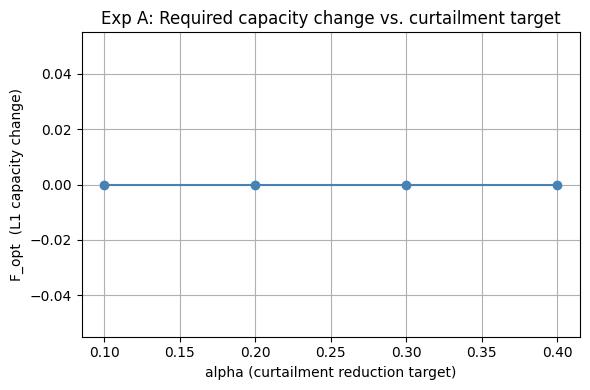

In [ ]:
sweep_A = {}
for alpha_sw in [0.10, 0.20, 0.30, 0.40]:
    ct_sw   = (1.0 - alpha_sw) * curt_0
    foil_sw = make_curt_foil(ct_sw, curt_flat_idx)
    ora_sw  = MatrixUCOracle(mat=mat, free_line_idx=b_free_idx,
                             foil_constr_fn=foil_sw, output_flag=0, eps_weak=1e-3)
    bs_sw   = UCBranchAndSandwichMatrix(
        mat=mat, oracle=ora_sw, b0=b0, bL0=bL, bU0=bU,
        free_line_idx=b_free_idx, foil_constr_fn=foil_sw, w=w,
        eps_b=1.0, eps_obj=1e-3, max_nodes=500, output_flag=0, verbose=False,
    )
    res_sw = bs_sw.run()
    sweep_A[alpha_sw] = res_sw["F_opt"]
    print(f"  alpha={alpha_sw:.0%}  F_opt={res_sw['F_opt']:.4f}  "
          f"gap={res_sw['gap']:.4f}  nodes={res_sw['nodes']}")

F_vals_A = [sweep_A[a] for a in sorted(sweep_A)]
mono_A   = all(F_vals_A[i] <= F_vals_A[i+1] + 1e-3 for i in range(len(F_vals_A)-1))
print(f"\nMonotonicity (F non-decreasing in alpha): {mono_A}")

plt.figure(figsize=(6, 4))
plt.plot(sorted(sweep_A.keys()), F_vals_A, "o-", color="steelblue")
plt.xlabel("alpha (curtailment reduction target)")
plt.ylabel("F_opt  (L1 capacity change)")
plt.title("Exp A: Required capacity change vs. curtailment target")
plt.grid(True); plt.tight_layout(); plt.show()

### A.6 - Dispatch plots at b_hat_A

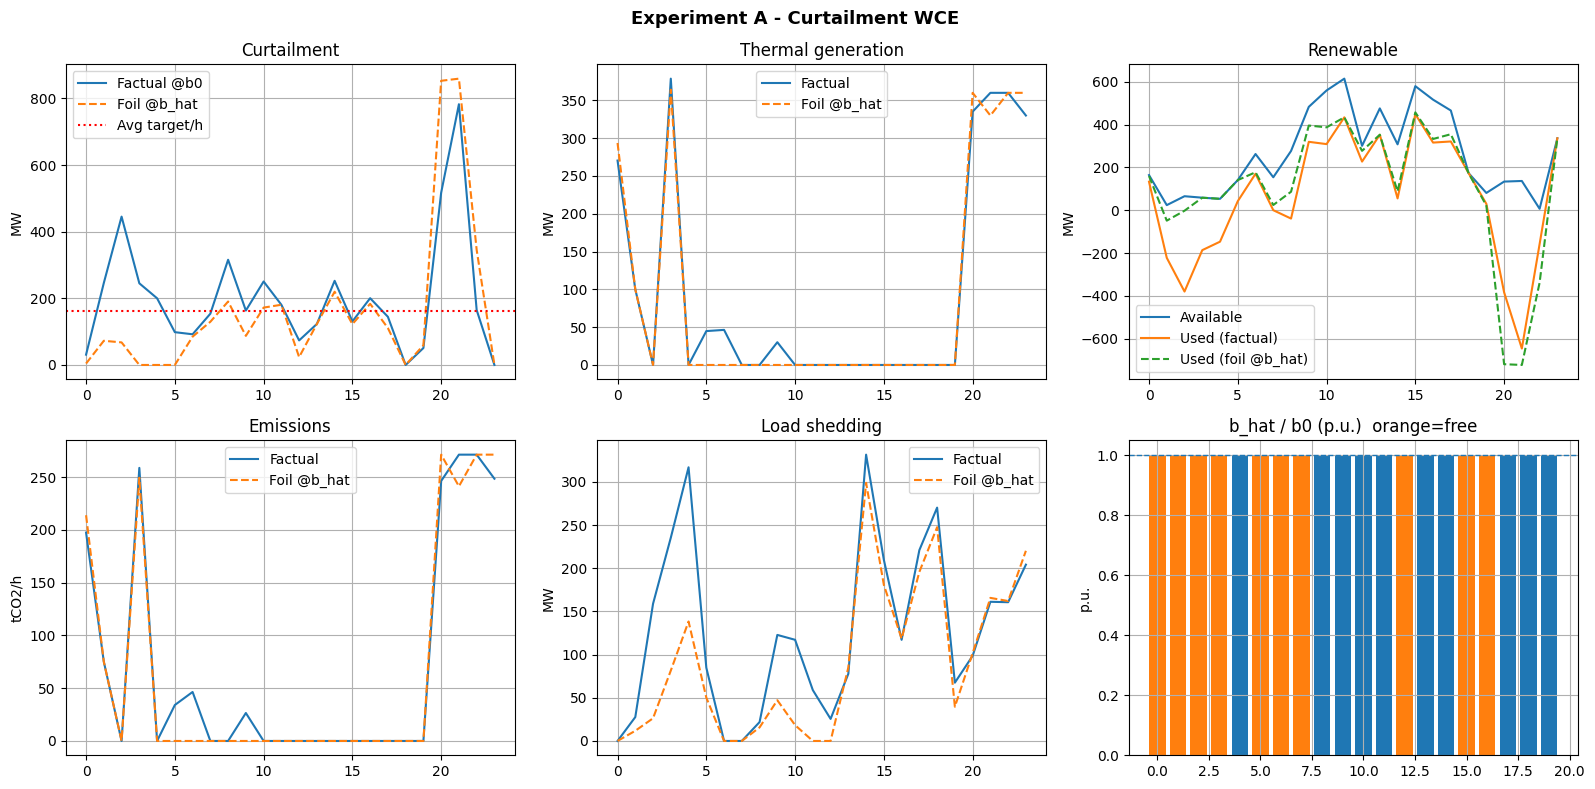

In [ ]:
def sol_totals(x_vec, DATA, idx, T, nR):
    p_th = x_vec[idx.p].sum(axis=0)
    if nR > 0:
        avail_mat = np.vstack([r.avail for r in DATA.rens])
        curt_mat  = x_vec[idx.curt]
        ren_used  = (avail_mat - curt_mat).sum(axis=0)
        ren_avail = avail_mat.sum(axis=0)
        curt_tot  = curt_mat.sum(axis=0)
    else:
        ren_used = ren_avail = curt_tot = np.zeros(T)
    er       = np.array([float(g.emission_rate) for g in DATA.gens], dtype=float)
    emis     = (er[:, None] * x_vec[idx.p]).sum(axis=0)
    shed_tot = x_vec[idx.shed].sum(axis=0)
    voll     = float(getattr(DATA, "voll", 20000.0))
    sp = x_vec[idx.splus]; sm = x_vec[idx.sminus]
    netload  = DATA.demand.sum(axis=0) + sp.sum(axis=0) - sm.sum(axis=0)
    return dict(thermal=p_th, ren_used=ren_used, ren_avail=ren_avail,
                curt=curt_tot, emissions=emis, shed=shed_tot,
                voll_cost=voll*shed_tot, netload=netload)

t_ax  = np.arange(T)
TS_F0 = sol_totals(x0,        DATA, idx, T, nR)
TS_PA = sol_totals(x_plain_A, DATA, idx, T, nR)
TS_DA = sol_totals(x_foil_A,  DATA, idx, T, nR)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Experiment A - Curtailment WCE", fontsize=13, fontweight="bold")

axes[0,0].plot(t_ax, TS_F0["curt"],  label="Factual @b0")
axes[0,0].plot(t_ax, TS_DA["curt"],  label="Foil @b_hat", linestyle="--")
axes[0,0].axhline(curt_target/T, color="red", linestyle=":", label="Avg target/h")
axes[0,0].set_title("Curtailment"); axes[0,0].set_ylabel("MW")
axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(t_ax, TS_F0["thermal"], label="Factual")
axes[0,1].plot(t_ax, TS_DA["thermal"], label="Foil @b_hat", linestyle="--")
axes[0,1].set_title("Thermal generation"); axes[0,1].set_ylabel("MW")
axes[0,1].legend(); axes[0,1].grid(True)

axes[0,2].plot(t_ax, TS_F0["ren_avail"], label="Available")
axes[0,2].plot(t_ax, TS_F0["ren_used"],  label="Used (factual)")
axes[0,2].plot(t_ax, TS_DA["ren_used"],  label="Used (foil @b_hat)", linestyle="--")
axes[0,2].set_title("Renewable"); axes[0,2].set_ylabel("MW")
axes[0,2].legend(); axes[0,2].grid(True)

axes[1,0].plot(t_ax, TS_F0["emissions"], label="Factual")
axes[1,0].plot(t_ax, TS_DA["emissions"], label="Foil @b_hat", linestyle="--")
axes[1,0].set_title("Emissions"); axes[1,0].set_ylabel("tCO2/h")
axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(t_ax, TS_F0["shed"], label="Factual")
axes[1,1].plot(t_ax, TS_DA["shed"], label="Foil @b_hat", linestyle="--")
axes[1,1].set_title("Load shedding"); axes[1,1].set_ylabel("MW")
axes[1,1].legend(); axes[1,1].grid(True)

colors_A = ["tab:orange" if ell in b_free_idx else "tab:blue" for ell in range(nL)]
pu_A = b_hat_A / np.maximum(b0, 1e-12)
axes[1,2].bar(np.arange(nL), pu_A, color=colors_A)
axes[1,2].axhline(1.0, linestyle="--", linewidth=1)
axes[1,2].set_title("b_hat / b0 (p.u.)  orange=free")
axes[1,2].set_ylabel("p.u."); axes[1,2].grid(True)

plt.tight_layout(); plt.show()

---
# Experiment B - Emissions Reduction Foil

**Foil**: total CO2 emissions <= (1 - alpha) * E0

**Question**: what is the smallest line-capacity expansion that makes
a low-emission dispatch cost-optimal?

> Requires non-zero `emission_rate` on at least some generators.
> If all rates are zero the cells below will skip gracefully and
> print a guidance message.

### B.1 - Baseline emissions and foil definition

In [ ]:
er_vec    = np.array([float(g.emission_rate) for g in DATA.gens], dtype=float)
E_factual = float(np.sum(er_vec[:, None] * x0[idx.p]))

print(f"Emission rates (tCO2/MWh): {er_vec}")
print(f"Factual total emissions   : {E_factual:.4f} tCO2")

RUN_EMISSIONS_EXPERIMENT = E_factual > 1e-6
if not RUN_EMISSIONS_EXPERIMENT:
    print()
    print("WARNING: All emission_rate are zero - Experiment B will be skipped.")
    print("To enable it, set non-zero values in DEFAULT_EMISSION_RATE_T_PER_MWH")
    print("inside uc_experiment_builders.py and reload.")
else:
    ALPHA_EMIS = 0.05          # 5% emissions reduction
    E_bar      = (1.0 - ALPHA_EMIS) * E_factual
    print(f"\nTarget ({ALPHA_EMIS*100:.0f}% reduction): {E_bar:.4f} tCO2")

    def make_emissions_foil(E_bar: float, er_vec: np.ndarray, idx):
        """
        Returns fn(m, x_vars, var_names) that adds:
            sum_{g,t}  er[g] * p[g,t]  <=  E_bar

        Uses idx.p[g, t] to map from (generator, hour) to z-index.
        """
        nG_ = len(er_vec)
        T_  = idx.p.shape[1]
        def _foil(m, x_vars, var_names):
            m.addConstr(
                gp.quicksum(
                    float(er_vec[g]) * x_vars[int(idx.p[g, t])]
                    for g in range(nG_) for t in range(T_)
                ) <= float(E_bar) + 1e-6,
                name="foil_emissions_cap",
            )
        return _foil

    foil_emis = make_emissions_foil(E_bar, er_vec, idx)

    # Feasibility check at b0
    _oe = MatrixUCOracle(mat=mat, free_line_idx=b_free_idx,
                         foil_constr_fn=foil_emis, output_flag=0)
    vFe_b0, xFe_b0 = _oe.solve_foil(b0)
    print(f"\nEmissions foil feasible at b0? {xFe_b0 is not None}")
    if xFe_b0 is not None:
        E_foil_b0 = float(np.sum(er_vec[:, None] * xFe_b0[idx.p]))
        print(f"  Emissions under foil@b0 = {E_foil_b0:.4f}  (target={E_bar:.4f})")

Emission rates (tCO2/MWh): [1.   0.5  0.5  0.76 0.76 1.  ]
Factual total emissions   : 1675.0603 tCO2

Target (5% reduction): 1591.3072 tCO2

Emissions foil feasible at b0? True
  Emissions under foil@b0 = 1087.7514  (target=1591.3072)


### B.2 - Run the Matrix B&S solver (emissions foil)

In [ ]:
if RUN_EMISSIONS_EXPERIMENT:
    oracle_B = MatrixUCOracle(
        mat=mat,
        free_line_idx=b_free_idx,
        foil_constr_fn=foil_emis,
        cache_decimals=3,
        output_flag=0,
        eps_weak=1e-3,
    )

    bs_B = UCBranchAndSandwichMatrix(
        mat=mat,
        oracle=oracle_B,
        b0=b0, bL0=bL, bU0=bU,
        free_line_idx=b_free_idx,
        foil_constr_fn=foil_emis,
        w=w,
        eps_b=1.0,
        eps_obj=1e-3,
        eps_weak=1e-3,
        max_nodes=500,
        master_time_limit=None,
        output_flag=0,
        verbose=True,
        oub_grid_pts=3,
    )

    res_B = bs_B.run()

    print("\n=== Experiment B - Emissions WCE ===")
    print(f"  success    : {res_B['success']}")
    print(f"  F_opt      : {res_B['F_opt']:.6f}")
    print(f"  global_LB  : {res_B['global_LB']:.6f}")
    print(f"  gap        : {res_B['gap']:.6f}")
    print(f"  nodes      : {res_B['nodes']}")

    b_hat_B = np.array(res_B["b_hat"], dtype=float) if res_B["success"] else None
    if b_hat_B is None:
        print("WARNING: No incumbent found. Try increasing max_nodes or widening bU.")
else:
    print("Experiment B skipped (zero emissions).")
    res_B = None; b_hat_B = None; oracle_B = None; bs_B = None

  [INC] b0: F=0.0000  v_plain=0.000  v_foil=0.000
    [INNER_UB] global best_inner_ub=0.0000
[BS-MAT] CERTIFIED: gLB=0.000000 >= bestF=0.000000

=== Experiment B - Emissions WCE ===
  success    : True
  F_opt      : 0.000000
  global_LB  : 0.000000
  gap        : 0.000000
  nodes      : 0


### B.3 - Report: which lines changed? (emissions)

In [ ]:
if b_hat_B is not None:
    F_B  = res_B["F_opt"]
    LB_B = res_B["global_LB"]
    gap_pct_B = 100.0 * max(0.0, F_B - LB_B) / max(abs(F_B), 1e-12)
    print(f"F_opt={F_B:.4f}  LB={LB_B:.4f}  gap={gap_pct_B:.2f}%  nodes={res_B['nodes']}\n")
    print_line_report(b_hat_B, b0, b_free_idx, DATA, util, label="Exp B: Emissions WCE")

F_opt=0.0000  LB=0.0000  gap=0.00%  nodes=0

--- Exp B: Emissions WCE ---
  (no line limits changed)


### B.4 - Verify WCE condition at b_hat_B

In [ ]:
if b_hat_B is not None:
    v_plain_B, x_plain_B = oracle_B.solve_plain(b_hat_B)
    v_foil_B,  x_foil_B  = oracle_B.solve_foil(b_hat_B)

    assert x_plain_B is not None and x_foil_B is not None

    E_plain_B = float(np.sum(er_vec[:, None] * x_plain_B[idx.p]))
    E_foil_B  = float(np.sum(er_vec[:, None] * x_foil_B[idx.p]))

    print("=== WCE verification (Exp B) ===")
    print(f"  v_plain(b_hat_B)     = {v_plain_B:.4f}")
    print(f"  v_foil (b_hat_B)     = {v_foil_B:.4f}")
    print(f"  |v_foil - v_plain|   = {abs(v_foil_B - v_plain_B):.6f}")
    print(f"  WCE satisfied        = {v_foil_B <= v_plain_B + 1e-3}")
    print()
    print(f"  Factual emissions    = {E_factual:.4f} tCO2")
    print(f"  Target emissions     = {E_bar:.4f} tCO2")
    print(f"  Foil emissions       = {E_foil_B:.4f} tCO2")
    print(f"  Emissions target met = {E_foil_B <= E_bar + 1e-4}")

=== WCE verification (Exp B) ===
  v_plain(b_hat_B)     = 0.0000
  v_foil (b_hat_B)     = 0.0000
  |v_foil - v_plain|   = 0.000000
  WCE satisfied        = True

  Factual emissions    = 1675.0603 tCO2
  Target emissions     = 1591.3072 tCO2
  Foil emissions       = 1087.7514 tCO2
  Emissions target met = True


### B.5 - alpha-sweep: emissions reduction vs. required capacity change

  alpha=2%  F_opt=0.0000  gap=0.0000  nodes=0
  alpha=5%  F_opt=0.0000  gap=0.0000  nodes=0
  alpha=10%  F_opt=0.0000  gap=0.0000  nodes=0
  alpha=15%  F_opt=0.0000  gap=0.0000  nodes=0

Monotonicity (F non-decreasing in alpha): True


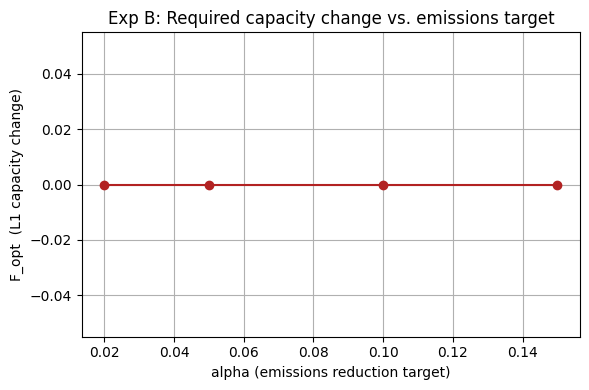

In [ ]:
if RUN_EMISSIONS_EXPERIMENT:
    sweep_B = {}
    for alpha_sw in [0.02, 0.05, 0.10, 0.15]:
        E_bar_sw  = (1.0 - alpha_sw) * E_factual
        foil_sw   = make_emissions_foil(E_bar_sw, er_vec, idx)
        ora_sw    = MatrixUCOracle(mat=mat, free_line_idx=b_free_idx,
                                   foil_constr_fn=foil_sw, output_flag=0, eps_weak=1e-3)
        bs_sw     = UCBranchAndSandwichMatrix(
            mat=mat, oracle=ora_sw, b0=b0, bL0=bL, bU0=bU,
            free_line_idx=b_free_idx, foil_constr_fn=foil_sw, w=w,
            eps_b=1.0, eps_obj=1e-3, max_nodes=300, output_flag=0, verbose=False,
        )
        res_sw = bs_sw.run()
        sweep_B[alpha_sw] = res_sw["F_opt"]
        print(f"  alpha={alpha_sw:.0%}  F_opt={res_sw['F_opt']:.4f}  "
              f"gap={res_sw['gap']:.4f}  nodes={res_sw['nodes']}")

    F_vals_B = [sweep_B[a] for a in sorted(sweep_B)]
    mono_B   = all(F_vals_B[i] <= F_vals_B[i+1] + 1e-3 for i in range(len(F_vals_B)-1))
    print(f"\nMonotonicity (F non-decreasing in alpha): {mono_B}")

    plt.figure(figsize=(6, 4))
    plt.plot(sorted(sweep_B.keys()), F_vals_B, "o-", color="firebrick")
    plt.xlabel("alpha (emissions reduction target)")
    plt.ylabel("F_opt  (L1 capacity change)")
    plt.title("Exp B: Required capacity change vs. emissions target")
    plt.grid(True); plt.tight_layout(); plt.show()

### B.6 - Dispatch plots at b_hat_B

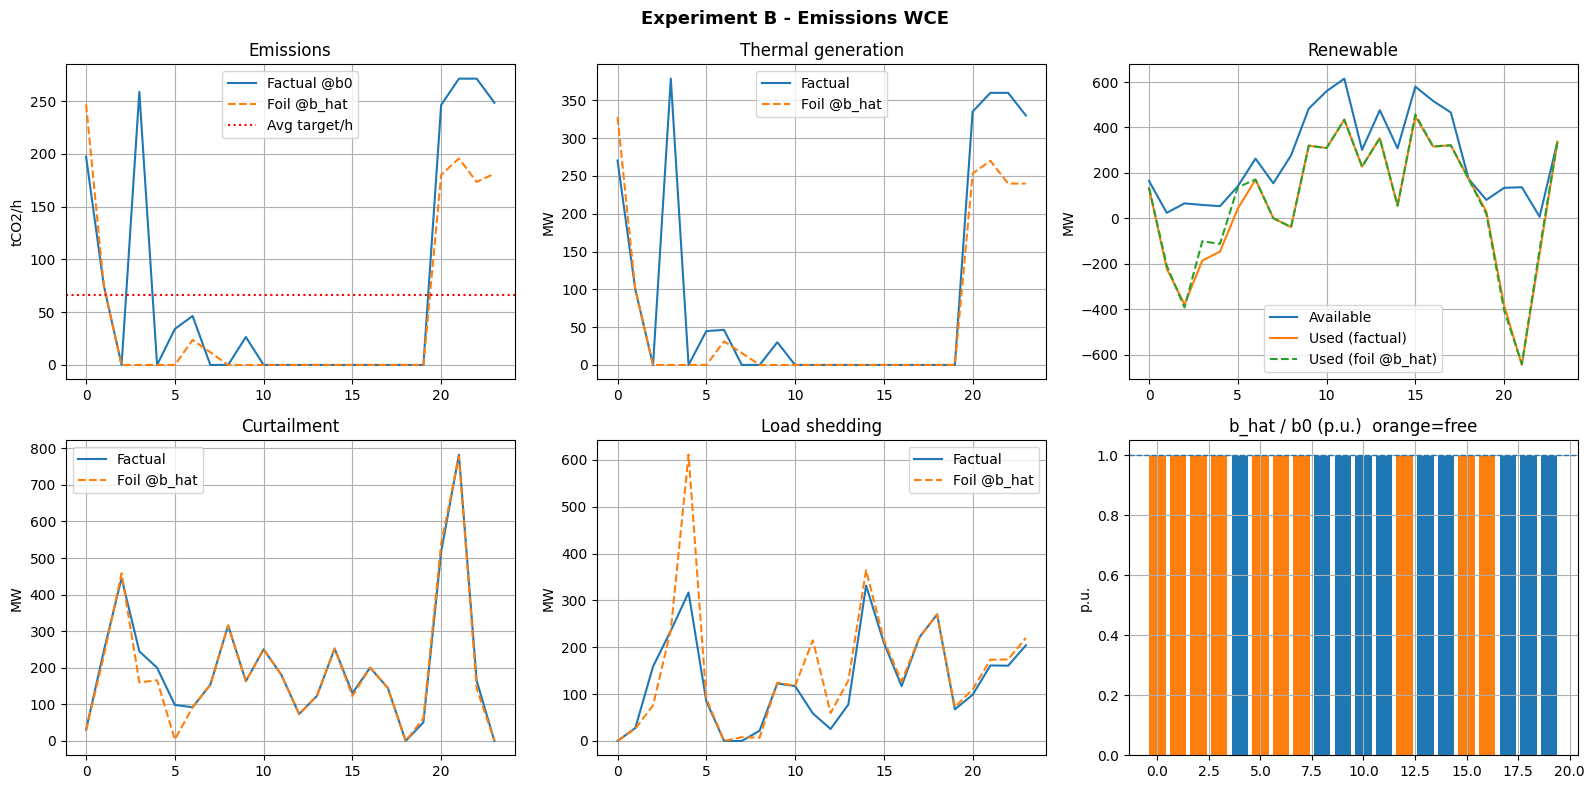

In [ ]:
if b_hat_B is not None:
    TS_PB = sol_totals(x_plain_B, DATA, idx, T, nR)
    TS_DB = sol_totals(x_foil_B,  DATA, idx, T, nR)

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("Experiment B - Emissions WCE", fontsize=13, fontweight="bold")

    axes[0,0].plot(t_ax, TS_F0["emissions"],  label="Factual @b0")
    axes[0,0].plot(t_ax, TS_DB["emissions"],  label="Foil @b_hat", linestyle="--")
    axes[0,0].axhline(E_bar/T, color="red", linestyle=":", label="Avg target/h")
    axes[0,0].set_title("Emissions"); axes[0,0].set_ylabel("tCO2/h")
    axes[0,0].legend(); axes[0,0].grid(True)

    axes[0,1].plot(t_ax, TS_F0["thermal"], label="Factual")
    axes[0,1].plot(t_ax, TS_DB["thermal"], label="Foil @b_hat", linestyle="--")
    axes[0,1].set_title("Thermal generation"); axes[0,1].set_ylabel("MW")
    axes[0,1].legend(); axes[0,1].grid(True)

    axes[0,2].plot(t_ax, TS_F0["ren_avail"], label="Available")
    axes[0,2].plot(t_ax, TS_F0["ren_used"],  label="Used (factual)")
    axes[0,2].plot(t_ax, TS_DB["ren_used"],  label="Used (foil @b_hat)", linestyle="--")
    axes[0,2].set_title("Renewable"); axes[0,2].set_ylabel("MW")
    axes[0,2].legend(); axes[0,2].grid(True)

    axes[1,0].plot(t_ax, TS_F0["curt"], label="Factual")
    axes[1,0].plot(t_ax, TS_DB["curt"], label="Foil @b_hat", linestyle="--")
    axes[1,0].set_title("Curtailment"); axes[1,0].set_ylabel("MW")
    axes[1,0].legend(); axes[1,0].grid(True)

    axes[1,1].plot(t_ax, TS_F0["shed"], label="Factual")
    axes[1,1].plot(t_ax, TS_DB["shed"], label="Foil @b_hat", linestyle="--")
    axes[1,1].set_title("Load shedding"); axes[1,1].set_ylabel("MW")
    axes[1,1].legend(); axes[1,1].grid(True)

    colors_B = ["tab:orange" if ell in b_free_idx else "tab:blue" for ell in range(nL)]
    pu_B = b_hat_B / np.maximum(b0, 1e-12)
    axes[1,2].bar(np.arange(nL), pu_B, color=colors_B)
    axes[1,2].axhline(1.0, linestyle="--", linewidth=1)
    axes[1,2].set_title("b_hat / b0 (p.u.)  orange=free")
    axes[1,2].set_ylabel("p.u."); axes[1,2].grid(True)

    plt.tight_layout(); plt.show()

---
# Section 6 - Side-by-side comparison: Exp A vs. Exp B

In [9]:
print("=" * 62)
print("COMPARISON: Curtailment WCE (A)  vs.  Emissions WCE (B)")
print("=" * 62)

row_fmt = "{:<30s}  {:>12s}  {:>12s}"
print(row_fmt.format("", "Exp A (curt)", "Exp B (emis)"))
print("-" * 62)

def _fmt(x):
    return f"{x:.4f}" if (x is not None and np.isfinite(x)) else "--"

F_B_val  = res_B["F_opt"]      if res_B else None
LB_B_val = res_B["global_LB"]  if res_B else None
gap_B    = res_B["gap"]        if res_B else None
nd_B     = str(res_B["nodes"]) if res_B else "--"

print(row_fmt.format("F_opt (L1 capacity change)", _fmt(res_A["F_opt"]),  _fmt(F_B_val)))
print(row_fmt.format("global_LB",                  _fmt(res_A["global_LB"]), _fmt(LB_B_val)))
print(row_fmt.format("gap",                         _fmt(res_A["gap"]),    _fmt(gap_B)))
print(row_fmt.format("nodes explored",              str(res_A["nodes"]),   nd_B))
print()

if b_hat_B is not None:
    print("Per-line capacity changes (delta p.u. = (b_hat - b0) / b0):")
    print(f"  {'ell':>4}  {'b0 (MW)':>10}  {'D_pu (A)':>10}  {'D_pu (B)':>10}")
    for ell in b_free_idx:
        dA = (b_hat_A[ell] - b0[ell]) / max(b0[ell], 1e-12)
        dB = (b_hat_B[ell] - b0[ell]) / max(b0[ell], 1e-12)
        print(f"  {ell:4d}  {b0[ell]:10.1f}  {dA:+10.4f}  {dB:+10.4f}")

COMPARISON: Curtailment WCE (A)  vs.  Emissions WCE (B)
                                Exp A (curt)  Exp B (emis)
--------------------------------------------------------------


NameError: name 'res_B' is not defined

---
# Section 7 - Monte-Carlo optimality check (both experiments)

In [ ]:
def mc_check(bs_solver, oracle, b_hat, b0, bL, bU, b_free_idx, n_samples=3000, label=""):
    """Sample random b vectors; flag any that beat F_opt while satisfying the foil."""
    F_opt = bs_solver.F(b_hat)
    rng   = np.random.default_rng(42)
    for _ in range(n_samples):
        b_s = b0.copy()
        for ell in b_free_idx:
            b_s[ell] = rng.uniform(bL[ell], bU[ell])
        ok, vp, vD = oracle.weak_ok(b_s)
        if ok and bs_solver.F(b_s) < F_opt - 1e-3:
            print(f"  [{label}] COUNTEREXAMPLE: F={bs_solver.F(b_s):.4f} < F_opt={F_opt:.4f}")
            return
    print(f"  [{label}] No counterexample in {n_samples} samples - solution looks correct.")

mc_check(bs_A, oracle_A, b_hat_A, b0, bL, bU, b_free_idx, label="Exp A")
if b_hat_B is not None:
    mc_check(bs_B, oracle_B, b_hat_B, b0, bL, bU, b_free_idx, label="Exp B")

---
# Comparison: Old B&S vs. Matrix B&S  (curtailment foil)

Runs **both methods** on the same curtailment foil, same hyperparameters, same free
lines and weights, then compares:
- **Solution quality** — F_opt, gap, b_hat per-line changes
- **Computational time** — wall-clock seconds for the full `.run()` call
- **Search efficiency** — nodes explored, unique oracle calls (plain + foil)

The old method (`UCBranchAndSandwichWCE_4b`) rebuilds the UC model from
`NetworkUCData` at every oracle call.  
The new method (`UCBranchAndSandwichMatrix`) reuses the extracted matrix
and never rebuilds the model.

---

### C.1 — Import old solver and define shared settings

In [10]:
import time
import importlib
import uc_branch_sandwich_4b
importlib.reload(uc_branch_sandwich_4b)
from uc_branch_sandwich_4b import UCBranchAndSandwichWCE_4b
from uc_pipeline import solve_uc_with_cost_4b

# Both methods will use these identical hyperparameters
SHARED_PARAMS = dict(
    eps_b             = 1.0,
    eps_obj           = 1e-3,
    eps_weak          = 1e-3,
    max_nodes         = 150,
    master_time_limit = None,
    output_flag       = 0,
    verbose           = False,
    oub_grid_pts      = 3,
)
print('Old solver imported. Shared params:', SHARED_PARAMS)


Old solver imported. Shared params: {'eps_b': 1.0, 'eps_obj': 0.001, 'eps_weak': 0.001, 'max_nodes': 150, 'master_time_limit': None, 'output_flag': 0, 'verbose': False, 'oub_grid_pts': 3}


### C.2 — Old-method oracle and foil function

In [11]:
from dataclasses import replace as dc_replace

def replace_line_limits(data, b_line):
    b_line = np.asarray(b_line, dtype=float).reshape(-1)
    return dc_replace(data, lines=[
        dc_replace(L, fmax=float(b_line[ell]))
        for ell, L in enumerate(data.lines)
    ])


class UCWeakWCEOracle:
    """Old-style oracle: rebuilds the full UC model from NetworkUCData at each unique b."""

    def __init__(self, data, cvec, idx, window_size, per_bus_neutrality,
                 u_init, p_init, on_t, off_t,
                 foil_extra_constr_fn=None, output_flag=0, cache_decimals=3):
        self.data = data;  self.cvec = np.asarray(cvec, float);  self.idx = idx
        self.window_size = int(window_size);  self.per_bus = bool(per_bus_neutrality)
        self.u_init = u_init;  self.p_init = p_init
        self.on_t = on_t;  self.off_t = off_t
        self.foil_fn   = foil_extra_constr_fn
        self.output_flag = int(output_flag)
        self.decimals  = int(cache_decimals)
        self.cache_plain = {};  self.cache_foil = {}

    def _key(self, b):
        return tuple(np.round(np.asarray(b, float), self.decimals))

    def _solve(self, b, with_foil):
        data_b = replace_line_limits(self.data, b)
        fn = self.foil_fn if with_foil else None
        m, sol, z = solve_uc_with_cost_4b(
            data=data_b, idx=self.idx, cvec=self.cvec,
            window_size=self.window_size, per_bus_neutrality=self.per_bus,
            u_init=self.u_init, p_init=self.p_init,
            on_time_init=self.on_t, off_time_init=self.off_t,
            extra_constr_fn=fn, output_flag=self.output_flag,
            time_limit=None, fmax_override=None,
        )
        if sol is None:
            return None, None, None
        return float(sol['obj']), np.array(z, float), sol

    def solve_plain(self, b):
        k = self._key(b)
        if k not in self.cache_plain:
            self.cache_plain[k] = self._solve(b, False)
        return self.cache_plain[k]

    def solve_foil(self, b):
        k = self._key(b)
        if k not in self.cache_foil:
            self.cache_foil[k] = self._solve(b, True)
        return self.cache_foil[k]


# Old-style foil: fn(m, var) where var is Gurobi var-dict keyed by (r,t)
def old_foil_curt(target):
    def _f(m, var):
        nR_ = len(DATA.rens)
        m.addConstr(
            gp.quicksum(var['curt'][r, t] for r in range(nR_) for t in range(T))
            <= float(target), name='foil_curt_cap',
        )
    return _f


oracle_old = UCWeakWCEOracle(
    data=DATA, cvec=cvec, idx=idx,
    window_size=window_size, per_bus_neutrality=per_bus_neutrality,
    u_init=u_init, p_init=p_init, on_t=on_t, off_t=off_t,
    foil_extra_constr_fn=old_foil_curt(curt_target),
    output_flag=0, cache_decimals=3,
)
print('Old oracle ready.')


Old oracle ready.


### C.3 — Run old solver

In [12]:
bs_old = UCBranchAndSandwichWCE_4b(
    oracle=oracle_old,
    data=DATA, idx=idx, cvec=cvec,
    foil_extra_constr_fn=old_foil_curt(curt_target),
    b0=b0, b_bounds=(bL, bU),
    b_free_idx=b_free_idx,
    w=w,
    **SHARED_PARAMS,
)

t0_old = time.perf_counter()
res_old = bs_old.run(
    window_size=window_size, per_bus_neutrality=per_bus_neutrality,
    u_init=u_init, p_init=p_init, on_t=on_t, off_t=off_t,
)
t_old = time.perf_counter() - t0_old

n_plain_old = len(oracle_old.cache_plain)
n_foil_old  = len(oracle_old.cache_foil)

print(f'Old B&S  ->  F_opt={res_old["F_opt"]:.4f}  gap={res_old["gap"]:.4f}  '
      f'nodes={res_old["nodes"]}  time={t_old:.1f}s  '
      f'plain_solves={n_plain_old}  foil_solves={n_foil_old}')

assert res_old['success'], 'Old solver found no incumbent.'
b_hat_old = np.array(res_old['b_hat'], dtype=float)


Old B&S  ->  F_opt=79.1394  gap=51.6923  nodes=150  time=262.7s  plain_solves=1225  foil_solves=1225


### C.4 — Run new (matrix) solver — fresh oracle for a fair time measurement

In [13]:
# Re-run with a fresh oracle so the cache is empty (fair timing)
oracle_new_cmp = MatrixUCOracle(
    mat=mat, free_line_idx=b_free_idx,
    foil_constr_fn=foil_curt,       # defined in Exp A cells
    cache_decimals=3, output_flag=0,
    eps_weak=SHARED_PARAMS['eps_weak'],
)

bs_new_cmp = UCBranchAndSandwichMatrix(
    mat=mat, oracle=oracle_new_cmp,
    b0=b0, bL0=bL, bU0=bU,
    free_line_idx=b_free_idx,
    foil_constr_fn=foil_curt,
    w=w,
    **SHARED_PARAMS,
)

t0_new = time.perf_counter()
res_new_cmp = bs_new_cmp.run()
t_new = time.perf_counter() - t0_new

n_plain_new = len(oracle_new_cmp._cache_plain)
n_foil_new  = len(oracle_new_cmp._cache_foil)

print(f'New B&S  ->  F_opt={res_new_cmp["F_opt"]:.4f}  gap={res_new_cmp["gap"]:.4f}  '
      f'nodes={res_new_cmp["nodes"]}  time={t_new:.1f}s  '
      f'plain_solves={n_plain_new}  foil_solves={n_foil_new}')

assert res_new_cmp['success'], 'New solver found no incumbent.'
b_hat_new = np.array(res_new_cmp['b_hat'], dtype=float)


KeyboardInterrupt: 

### C.5 — Results table

In [ ]:
b_diff_max = float(np.max(np.abs(b_hat_old[b_free_idx] - b_hat_new[b_free_idx])))
b_match    = 'YES' if b_diff_max < 1.0 else f'NO  (max diff={b_diff_max:.2f} MW)'
speedup    = t_old / t_new if t_new > 0 else float('inf')

rows = [
    ('Metric',                      'Old B&S',                          'New (matrix) B&S',           'Notes'),
    ('-'*24,                        '-'*20,                             '-'*20,                       '-'*26),
    ('F_opt',                       f"{res_old['F_opt']:.4f}",          f"{res_new_cmp['F_opt']:.4f}", 'lower is better'),
    ('Gap',                         f"{res_old['gap']:.4f}",            f"{res_new_cmp['gap']:.4f}",  'lower is better'),
    ('Nodes explored',              str(res_old['nodes']),              str(res_new_cmp['nodes']),    ''),
    ('Plain MIP solves (unique)',   str(n_plain_old),                   str(n_plain_new),             'cached; each = 1 UC solve'),
    ('Foil MIP solves  (unique)',   str(n_foil_old),                    str(n_foil_new),              'cached; each = 1 UC+foil solve'),
    ('Wall-clock time (s)',         f'{t_old:.1f}',                     f'{t_new:.1f}',               f'speed-up: {speedup:.2f}x'),
    ('b_hat agreement',             '—',                                b_match,                      'max |old-new| < 1 MW => same'),
]

col_w = [26, 22, 22, 30]
for r in rows:
    print('  '.join(str(v).ljust(w) for v, w in zip(r, col_w)))


### C.6 — Bar chart comparison

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    ('F_opt',               res_old['F_opt'],   res_new_cmp['F_opt'],   'F_opt (capacity change)'),
    ('Gap',                 res_old['gap'],     res_new_cmp['gap'],     'Optimality gap'),
    ('Nodes',               res_old['nodes'],   res_new_cmp['nodes'],   'Nodes explored'),
    ('Plain solves',        n_plain_old,        n_plain_new,            'Plain MIP solves (unique)'),
    ('Foil solves',         n_foil_old,         n_foil_new,             'Foil MIP solves (unique)'),
    ('Time (s)',            t_old,              t_new,                  'Wall-clock time (s)'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.suptitle('Old B&S vs. Matrix B&S  —  curtailment foil, same hyperparameters',
             fontsize=12, fontweight='bold')
colors = ['#4C72B0', '#DD8452']

for ax, (key, v_old, v_new, title) in zip(axes.flat, metrics):
    bars = ax.bar(['Old B&S', 'Matrix B&S'], [v_old, v_new],
                  color=colors, width=0.45, alpha=0.88)
    # value labels on bars
    for bar, val in zip(bars, [v_old, v_new]):
        if np.isfinite(float(val)) and float(val) > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() * 1.03,
                    f'{val:.3g}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### C.7 — Per-line b_hat comparison

In [ ]:
dpu_old = (b_hat_old - b0) / np.maximum(b0, 1e-12)
dpu_new = (b_hat_new - b0) / np.maximum(b0, 1e-12)

x_ax       = np.arange(len(b_free_idx))
tick_lbls  = [f'ell={ell}' for ell in b_free_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
fig.suptitle('b_hat per-line comparison  (curtailment foil)', fontsize=11, fontweight='bold')

# Absolute MW
ax = axes[0]
ax.bar(x_ax - 0.2, b_hat_old[b_free_idx], 0.38,
       label='Old B&S',    color='#4C72B0', alpha=0.85)
ax.bar(x_ax + 0.2, b_hat_new[b_free_idx], 0.38,
       label='Matrix B&S', color='#DD8452', alpha=0.85)
ax.step(x_ax, b0[b_free_idx], where='mid',
        color='black', linewidth=1.8, linestyle='--', label='b0 (original)')
ax.set_xticks(x_ax); ax.set_xticklabels(tick_lbls, rotation=30, ha='right')
ax.set_ylabel('fmax (MW)'); ax.set_title('Capacity at b_hat')
ax.legend(fontsize=8); ax.grid(axis='y', linestyle='--', alpha=0.5)

# Delta p.u.
ax = axes[1]
ax.bar(x_ax - 0.2, dpu_old[b_free_idx], 0.38,
       label='Old B&S',    color='#4C72B0', alpha=0.85)
ax.bar(x_ax + 0.2, dpu_new[b_free_idx], 0.38,
       label='Matrix B&S', color='#DD8452', alpha=0.85)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x_ax); ax.set_xticklabels(tick_lbls, rotation=30, ha='right')
ax.set_ylabel('(b_hat - b0) / b0'); ax.set_title('Per-unit change')
ax.legend(fontsize=8); ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

print(f'Max |b_hat_old - b_hat_new| on free lines: {b_diff_max:.4f} MW')
print(f'Solutions agree (< 1 MW):  {b_diff_max < 1.0}')
